# HW1: Logistic Regression

This class is about models and algorithms for discrete data. This homework will have all 3 ingredients:
* **Data**: the results from all college football games in the 2023 season
* **Model**: The *Bradely-Terry* model for predicting the winners of football game. The Bradley-Terry model is just logistic regression.
* **Algorithm**: We will implement two ways of fitting logistic regression: gradient descent and Newton's method

## The Bradley-Terry Model

In the Bradley-Terry Model, we give team $k$ a team-effect $\beta_k$. Basically, higher $\beta_k$ (relatively speaking), means that team $k$ is a better team.
The Bradley-Terry model formalizes this intution by modeling the log odds of team $k$ beating team $k'$ by the difference in their team effects, $\beta_k - \beta_{k'}$.

Let $i = 1,\ldots, n$ index games, and let $h(i) \in \{1,\ldots,K\}$ and $a(i) \in \{1,\ldots,K\}$ denote the indices of the home and away teams, respectively.
Let $Y_i \in \{0,1\}$ denote whether the home team won.
Under the Bradley-Terry model,
\begin{equation*}
  Y_i \sim \mathrm{Bern}\big(\sigma(\beta_{h(i)} - \beta_{a(i)}) \big),
\end{equation*}
where $\sigma(\cdot)$ is the sigmoid function. We can view this model as a logistic regression model with covariates $x_i \in \mathbb{R}^K$ where,
\begin{align*}
x_{i,k} &=
\begin{cases}
+1 &\text{if } h(i) = k \\
-1 &\text{if } a(i) = k \\
0 &\text{o.w.},
\end{cases}
\end{align*}
and parameters $\beta \in \mathbb{R}^K$.

## Data

We use the results of college football games in the fall 2023 season, which are available from the course github page and loaded for you below.

The data comes as a list of the outcomes of individual games. You'll need to wrangle the data to get it into a format that you can feed into the Bradley-Terry model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
allgames = pd.read_csv("01_allgames.csv")

In [3]:
allgames.head().T

,0,1,2,3,4
Id,401550883,401525434,401540199,401520145,401525450
Season,2023,2023,2023,2023,2023
Week,1,1,1,1,1
Season Type,regular,regular,regular,regular,regular
Start Date,2023-08-26T17:00:00.000Z,2023-08-26T18:30:00.000Z,2023-08-26T19:30:00.000Z,2023-08-26T21:30:00.000Z,2023-08-26T23:00:00.000Z
Start Time Tbd,False,False,False,False,False
Completed,True,True,True,True,True
Neutral Site,False,True,True,False,False
Conference Game,False,False,False,True,False
Attendance,NaN,49000.0,NaN,17982.0,15356.0


## Problem 0: Preprocessing

Preprocess the data to drop games with nan scores, construct the covariate matrix $X$, construct the response vector $y$, and do any other preprocessing you find useful.

In [4]:
allgames.values

array([[401550883, 2023, 1, ..., nan, nan, nan],
       [401525434, 2023, 1, ..., 1.3469076611, nan, nan],
       [401540199, 2023, 1, ..., 6.8969089314, nan, nan],
       ...,
       [401539478, 2023, 14, ..., 8.5801041578, nan, 'ACC Championship'],
       [401539480, 2023, 14, ..., 2.7196474905, nan,
        'Big Ten Championship'],
       [401520445, 2023, 15, ..., 5.136619754, nan, nan]],
      shape=(3599, 33), dtype=object)

In [5]:
# Frist, We drop games with NaN scores.
df = allgames.dropna(subset=["Home Points", "Away Points", "Neutral Site"])
# Drop Bias(Home Points == Score Points)
df = df[df["Home Points"] != df["Away Points"]]
# Drop Bias(Neutral Site == True)
df = df[df["Neutral Site"] != True] # If we not add line, then Our calculation results will be unstable.

# Second, We Construct the response vector $y$.
Y = torch.tensor((df["Home Points"] > df["Away Points"]).astype(int).values, dtype=torch.float32).unsqueeze(1)

# Last, We Construct the covariate matrix $X$.
teams = sorted(set(df["Home Team"]) | set(df["Away Team"])) # Deduplication
team_idx = {team: i for i, team in enumerate(teams)}
T = len(teams) # Team T

X = torch.zeros(len(df), T) # Design Matrix

# We need to organize the data into a format suitable for Bradley-Terry Model.
df = df.reset_index(drop=True)
for k, r in df.iterrows():
  i = team_idx[r["Home Team"]]
  j = team_idx[r["Away Team"]]
  X[k, i] = 1
  X[k, j] = -1

In [6]:
df.head().T

,0,1,2,3,4
Id,401520145,401525450,401532392,401540628,401520147
Season,2023,2023,2023,2023,2023
Week,1,1,1,1,1
Season Type,regular,regular,regular,regular,regular
Start Date,2023-08-26T21:30:00.000Z,2023-08-26T23:00:00.000Z,2023-08-26T23:00:00.000Z,2023-08-26T23:00:00.000Z,2023-08-26T23:30:00.000Z
Start Time Tbd,False,False,False,False,False
Completed,True,True,True,True,True
Neutral Site,False,False,False,False,False
Conference Game,True,False,False,False,False
Attendance,17982.0,15356.0,23867.0,NaN,21407.0


In [7]:
X.shape, Y.shape

(torch.Size([3469, 691]), torch.Size([3469, 1]))

## Problem 1: Loss function

Write a function to compute the loss, $L(\beta)$ defined be

\begin{equation*}
  L(\beta) = -\frac{1}{n} \sum_{i=1}^n \log p(y_i \mid x_i; \beta) + \frac{\gamma}{2} \| \beta \|_2^2
\end{equation*}
where $\gamma$ is a hyperparameter that controls the strength of your $\ell_2$ regularization.

You may want to use the `torch.distributions.Bernoulli` class.

In [8]:
def compute_the_loss(x, y, beta, gamma):
  avg_log_likelihood = torch.distributions.Bernoulli(probs=torch.sigmoid(x @ beta)).log_prob(y).mean()
  return -1 * avg_log_likelihood + gamma / 2 * (torch.norm(beta, 2)**2)

## Problem 2: Gradient Descent

### Problem 2.1 Implementing and checking your gradients


Write a function to compute the gradient of the average negative log likelihood and check your output against the results obtained by PyTorch's automatic differentiation functionality.

Answer:
\begin{align*}
  \nabla L(\beta) & = \nabla\left( -\frac{1}{n} \sum_{i=1}^n \log p(y_i \mid x_i; \beta) + \frac{\gamma}{2} \| \beta \|_2^2\right) \\
  &= -\frac{1}{n} \sum_{i=1}^n \left(y_i - \sigma(x_i^T \beta) \right)x_i + \gamma\beta
\end{align*}
We rewrite it in vector form:
\begin{align*}\nabla L(\beta) = -\frac{1}{n} X^T (y - \sigma(X\beta)) + \gamma\beta\end{align*}


In [9]:
def compute_the_gradient(x, y, beta, gamma):
  return -1 / (y.shape[0]) * (x.T @ (y - torch.sigmoid(x @ beta))) + gamma * beta

In [10]:
# check output
torch.manual_seed(42)
gamma = 0.1

beta = torch.rand([X.shape[1], 1], dtype=torch.float32, requires_grad=True)
loss = compute_the_loss(X, Y, beta, gamma)
loss.backward()
auto_grad = beta.grad

m_gradient = compute_the_gradient(X, Y, beta, gamma)
torch.allclose(m_gradient, auto_grad)

True

In [11]:
beta.shape

torch.Size([691, 1])

### Problem 2.2: Implement Gradient Descent


Now, use gradient descent to fit your Bradley-Terry model to the provided data.

Deliverables for this question:
1. Code the implements gradient descent to fit your Bradley-Terry model to the provided data.
2. A plot of the loss curve of your algorithm and a brief discussion if it makes sense or not
3. A plot of the histogram of the fitted values of $\beta$
4. The top 10 teams from your ranking, and a discussion of whether this ranking makes sense or not.

In [12]:
# your code here (you can use multiple code and markdown cells to organize your answer)
# 1. Code the implements gradient descent to fit your Bradley-Terry model to the provided data.
gamma = 0.01
beta = torch.zeros([X.shape[1], 1], dtype=torch.float32, requires_grad=True)
lr = 3
num_iters = 1000

losses = []
for _ in range(num_iters):
  c_gradient = compute_the_gradient(X, Y, beta, gamma)
    
  with torch.no_grad():
    new_beta = beta - lr * c_gradient
    
    if torch.allclose(beta, new_beta, rtol=1e-4):
      break
  
    beta.copy_(new_beta)
  
  losses.append(compute_the_loss(X, Y, beta, gamma).item())

Text(0, 0.5, 'loss')

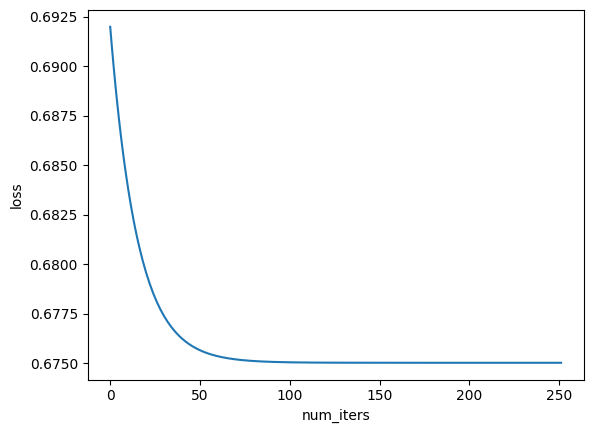

In [13]:
# 2. A plot of the loss curve of your algorithm and a brief discussion if it makes sense or not
plt.plot(torch.as_tensor(losses))
plt.xlabel("num_iters")
plt.ylabel("loss")

In [14]:
len(beta)

691

In [15]:
df_beta = pd.DataFrame({"Team": teams, "Effect": beta.detach().numpy().flatten()})
df_beta

,Team,Effect
0,Abilene Christian,-0.014262
1,Adams State,-0.067192
2,Adrian,-0.106660
3,Air Force,0.053968
4,Akron,-0.107294
...,...,...
686,Worcester Polytechnic,-0.052772
687,Worcester State College,-0.094957
688,Wyoming,0.054157
689,Yale,0.053426


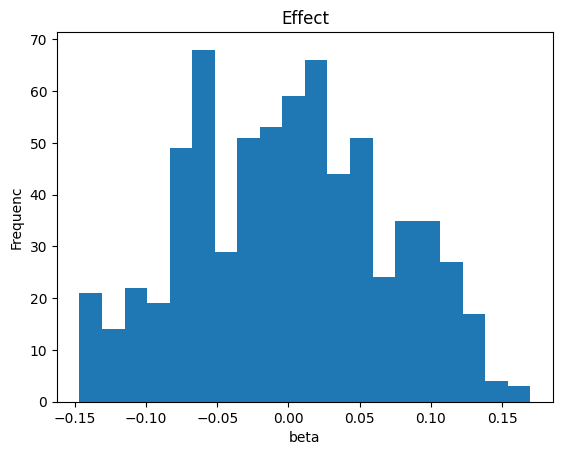

In [16]:
# 3. A plot of the histogram of the fitted values of $\beta$
plt.hist(df_beta["Effect"], bins=20) # $bins ==> k = \lceil \log_2(n) + 1 \rceil$
plt.title("Effect")
plt.xlabel("beta")
plt.ylabel("Frequenc")
plt.show()

In [17]:
# 4. The top 10 teams from your ranking, and a discussion of whether this ranking makes sense or not.
teams_10_gd = df_beta.sort_values(by="Effect", ascending=False).head(10)
teams_10_gd

,Team,Effect
303,Liberty,0.169892
631,Washington,0.160030
347,Michigan,0.159504
558,Texas,0.147884
214,Georgia,0.147814
129,Colorado Mines,0.147378
196,Florida State,0.145838
509,South Dakota State,0.136141
271,Johns Hopkins,0.135715
5,Alabama,0.134950


## Problem 3: Newton's Method

Now, use Newton's method to fit your Bradley-Terry model to the provided data.


### Problem 3.1 The Hessian



#### Problem 3.1.1. Implement and check the Hessian
Write a function to compute the Hessian of the average negative log likelihood and check your answer against the output of `from torch.autograd.functional.hessian`.

Our solution comes from Logistic Regression — STATS 305B_ Models and Algorithms for Discrete Data--Convexity of the Log Likelhood

Answer:
\begin{align*}
  \nabla L(\beta) & = -\frac{1}{n} \sum_{i=1}^n \left(y_i - \sigma(x_i^T \beta) \right)x_i + \gamma\beta
\end{align*}
We need compute the Hessian,
\begin{align*}
  \nabla^{2} L(\beta) & = \frac{1}{n} \sum_{i=1}^n \sigma' (\beta^{T}x_i)x_i x^{T}_i + \gamma\mathbf{I}_{dim(\beta)}
\end{align*}
We know $\sigma'(a)=\sigma(a)(1-\sigma(a))$, So we get
\begin{align*}
  \nabla^2 L(\beta) &= \frac{1}{n} \sum_{i=1}^{n} \sigma(\beta^\top x_i) \big(1 - \sigma(\beta^\top x_i)\big) x_i x_i^\top + \gamma\mathbf{I}_{dim(\beta)} \\
  &= \frac{1}{n} \sum_{i=1}^{n} w_i x_i x_i^\top + \gamma\mathbf{I}_{dim(\beta)}
\end{align*}
where $w=\sigma(\beta^\top x_i) \big(1 - \sigma(\beta^\top x_i)\big)$, We rewrite it in vector form:
\begin{align*}
  \nabla^2 L(\beta) & = \frac{1}{n} X^TWX + \gamma\mathbf{I}_{dim(\beta)}
\end{align*}
where $W_{ij} = w_{ij}$, a diagonal matrix.


In [18]:
beta.shape[0]

691

In [19]:
def compute_the_hessian(X, Y, beta, gamma):
  a = torch.sigmoid(X @ beta).squeeze()
  W = torch.diag(a * (1 - a))
  return (1 / Y.shape[0]) * (X.T @ W @ X) + gamma * torch.eye(beta.shape[0])

In [20]:
# check output
torch.manual_seed(42)
gamma = 0.1

beta = torch.rand([X.shape[1], 1], dtype=torch.float32, requires_grad=True)
h_left = compute_the_hessian(X, Y, beta, gamma)

h_loss = lambda beta: compute_the_loss(X, Y, beta, gamma)
right_h = torch.autograd.functional.hessian(h_loss, beta).squeeze()

torch.allclose(h_left, right_h)

True

In [21]:
h_left.shape[0], right_h.shape[0]

(691, 691)

#### Problem 3.1.2: Positive definiteness

Compute the Hessian at the point $\beta = 0$ without regularization (set $\gamma = 0$). Unless you've done sort of pre-processing, it's probably singular.

In [22]:
gamma=0
beta=torch.zeros([X.shape[1], 1], dtype=torch.float32, requires_grad=True)

h = compute_the_hessian(X, Y, beta, gamma)

print("rank: ", torch.linalg.matrix_rank(h))
print("Singular: ", torch.linalg.det(h))

rank:  tensor(687)
Singular:  tensor(-0., grad_fn=<LinalgDetBackward0>)


In [23]:
h.shape[0] # not full rank

691

#### Problem 3.1.3

Describe intuitively and mathematically what it means for the Hessian of the negative log likelihood to be singular in the context of this data and model

Answer: Mathematically, a Hessian singular matrix is ​​non-invertible, has no unique solution, and undergoes a geometrical collapse. Our information is lost during this collapse process, making it impossible to deduce the original state.

Statistically, our rugby team could potentially have a perfect record or a perfect record.

#### Problem 3.1.4

Give a hypothesis for why the Hessian in this dataset and model is singular, and provide empirical evidence to support your hypothesis.

Answer:
Our covariate matrix X is linearly correlated; it is not full rank.

In [24]:
# your code here
print("rank: ", torch.linalg.matrix_rank(X)) # X not column full rank

rank:  tensor(687)


#### Problem 3.1.5

Explain why the Hessian is invertible when $\gamma > 0$.

Answer: When $\gamma > 0$, since our original Hessian matrix is ​​positive semi-definite ($\ge 0$), $\gamma$ will push all the eigenvalues ​​upwards, and the matrix then becomes strictly positive definite ($>0$).

### Problem 3.2: Implement Newton's method

Now, use Newton's method to fit your $\ell_2$-regularized Bradley-Terry model to the provided data.

Deliverables for this question:
1. Code the implements Newton's method to fit your Bradley-Terry model to the provided data.
2. A plot of the loss curves from Newton's method and from gradient descent, using the same regularization strength $\gamma$ and initialization $\beta_0$. Briefly discuss the results and compare their rates of convergence.
3. A plot of the histogram of the fitted values of $\beta$
4. The top 10 teams from your ranking, and a discussion of whether this ranking makes sense or not.

In [25]:
# your code here (you can use multiple code and markdown cells to organize your answer)
# 1. Code the implements Newton's method to fit your Bradley-Terry model to the provided data.
gamma = 0.01
beta = torch.zeros([X.shape[1], 1], dtype=torch.float32, requires_grad=True)
lr = 0.3
num_iters = 100

newton_losses = []
for _ in range(num_iters):
  hessian = compute_the_hessian(X, Y, beta, gamma)
  a_gradient = compute_the_gradient(X, Y, beta, gamma)
  
  with torch.no_grad():
    new_beta = beta - lr * torch.linalg.solve(hessian, a_gradient)
    
    if torch.allclose(beta, new_beta, rtol=1e-4):
      break
    
    beta.copy_(new_beta)
  
  beta, newton_losses.append(compute_the_loss(X, Y, beta, gamma).item())

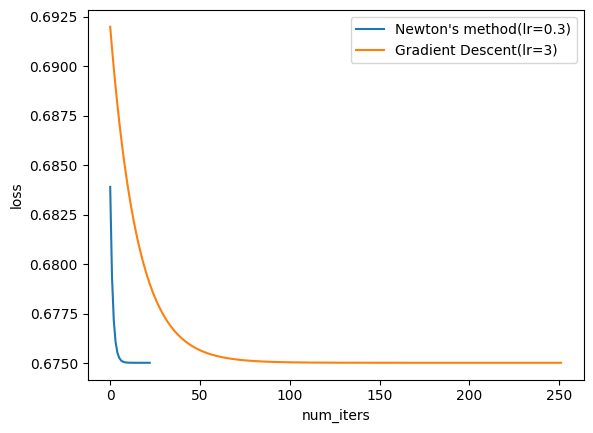

In [26]:
# 2. A plot of the loss curves from Newton's method and from gradient descent,
# using the same regularization strength $\gamma$ and initialization $\beta_0$.
# Briefly discuss the results and compare their rates of convergence.
plt.plot(torch.as_tensor(newton_losses), label="Newton's method(lr=0.3)")
plt.plot(torch.as_tensor(losses), label="Gradient Descent(lr=3)")
plt.xlabel("num_iters")
plt.ylabel("loss")
plt.legend()

In [27]:
df_newton_beta = pd.DataFrame({"Team": teams, "Effect": beta.detach().numpy().flatten()})
df_newton_beta

,Team,Effect
0,Abilene Christian,-0.014263
1,Adams State,-0.067192
2,Adrian,-0.106657
3,Air Force,0.053968
4,Akron,-0.107292
...,...,...
686,Worcester Polytechnic,-0.052770
687,Worcester State College,-0.094959
688,Wyoming,0.054158
689,Yale,0.053424


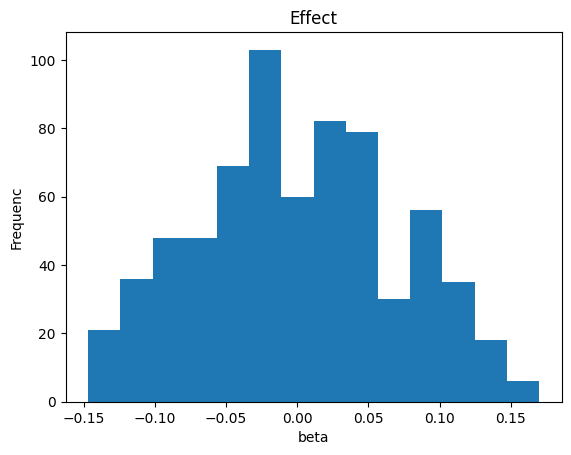

In [28]:
# 3. A plot of the histogram of the fitted values of $\beta$.
plt.hist(df_newton_beta["Effect"], bins='auto') # $bins ==> k = \lceil \log_2(n) + 1 \rceil$ or 'auto'
plt.title("Effect")
plt.xlabel("beta")
plt.ylabel("Frequenc")
plt.show()

In [29]:
# 4. The top 10 teams from your ranking, and a discussion of whether this ranking makes sense or not.
teams_10_n_gd = df_newton_beta.sort_values(by="Effect", ascending=False).head(10)
teams_10_n_gd

,Team,Effect
303,Liberty,0.169881
631,Washington,0.160027
347,Michigan,0.159500
558,Texas,0.147884
214,Georgia,0.147814
129,Colorado Mines,0.147376
196,Florida State,0.145834
509,South Dakota State,0.136144
271,Johns Hopkins,0.135717
5,Alabama,0.134951


Therefore, let's compare the final values ​​calculated by gradient descent and Newton's method.

In [30]:
compare_ = pd.concat(
    [teams_10_gd, teams_10_n_gd],
    axis=1,
    keys=["GD", "Newton"]
)
compare_

GD                        Newton          
                   Team    Effect                Team    Effect
303             Liberty  0.169892             Liberty  0.169881
631          Washington  0.160030          Washington  0.160027
347            Michigan  0.159504            Michigan  0.159500
558               Texas  0.147884               Texas  0.147884
214             Georgia  0.147814             Georgia  0.147814
129      Colorado Mines  0.147378      Colorado Mines  0.147376
196       Florida State  0.145838       Florida State  0.145834
509  South Dakota State  0.136141  South Dakota State  0.136144
271       Johns Hopkins  0.135715       Johns Hopkins  0.135717
5               Alabama  0.134950             Alabama  0.134951

## Problem 4: Model criticism and revision

Let's take another look the Bradley-Terry model from earlier and think about improvements we can make.


### Problem 4.1: Improvements to Bradley-Terry Model
Choose one way to improve the Bradley-Terry model. Discuss *a priori* why you think this change will improve the model and implement your change.

Answer:

We replace the original
\begin{equation*}
  Y_i \sim \mathrm{Bern}\big(\sigma(\beta_{h(i)} - \beta_{a(i)}) \big)
\end{equation*}
with
\begin{equation*} 
  Y_i \sim \mathrm{Bern}\big(\sigma(f_\theta(s_i) - f_\theta(s_j))\big)
\end{equation*}
where, $s_i = f_\theta(x_i)$, $f_\theta$ is the neural network, $x_i$ is the team feature, and $s_i$ is the scalar score.

Our parameter $\theta$ is shared, and our model requires input features. This type of model is called a Neural Bradley-Terry Model, and our implementation above uses pointwise scoring.

We should re-preprocess the data (each team $k$ → one feature vector $z_k$)


<font color="red">However, after implementing the neural network version, our neural network caused the original standard model to lose its convex optimization properties.</font> This meant that the final calculated value was a local optimum, making our results completely inconsistent with the standard model. Therefore, I decided to remove the neural network (MLP) and implement the model using only <span style="color:blue; font-weight:bold">nn.Embedding + self.home_adv</span> (home advantage, a custom parameter; since we removed the neutral site, we don't need to set it to 0). For our improved task, our self.home_adv is fully satisfactory, while maintaining interpretability.

In [31]:
df_n = allgames.dropna(subset=["Home Points", "Away Points", "Neutral Site"])
df_n = df_n[df_n["Home Points"] != df_n["Away Points"]]
df_n = df_n[df_n["Neutral Site"] != True]

Y_N = torch.tensor((df_n["Home Points"] > df_n["Away Points"]).astype(int).values, dtype=torch.float32).unsqueeze(1)

teams = sorted(set(df_n["Home Team"]) | set(df_n["Away Team"]))
team_idx = {team: i for i, team in enumerate(teams)}
T_N = len(teams)

df_n = df_n.reset_index(drop=True)

home_idx = []
away_idx = []

for _, r in df_n.iterrows():
  home_idx.append(team_idx[r["Home Team"]])
  away_idx.append(team_idx[r["Away Team"]])

home_idx = torch.tensor(home_idx, dtype=torch.long)
away_idx = torch.tensor(away_idx, dtype=torch.long)

In [32]:
home_idx.shape, away_idx.shape

(torch.Size([3469]), torch.Size([3469]))

In [33]:
# Model Implement
class BT(nn.Module):
  def __init__(self, num_teams):
        super().__init__()
        self.strength = nn.Embedding(num_teams, 1)

        nn.init.zeros_(self.strength.weight)
        
        self.home_adv = nn.Parameter(torch.tensor([0.2])) 

  def forward(self, h_idx, a_idx):
        s_i = self.strength(h_idx)
        s_j = self.strength(a_idx)

        return s_i - s_j + self.home_adv

In [34]:
model = BT(num_teams=T_N)
loss_f = nn.BCEWithLogitsLoss()

optimizer = optim.SGD(model.parameters(), lr=1.0, weight_decay=1e-2) 
losses_epoch = []
num_iters = 1600

model.train()
for _ in range(1600):
    optimizer.zero_grad()
    
    logits = model(home_idx, away_idx)
    
    loss = loss_f(logits, Y_N)
    
    loss.backward()
    
    optimizer.step()
    
    losses_epoch.append(loss.item())

print(f"Final train-loss: {losses_epoch[-1]:.4f}")

Final train-loss: 0.6494


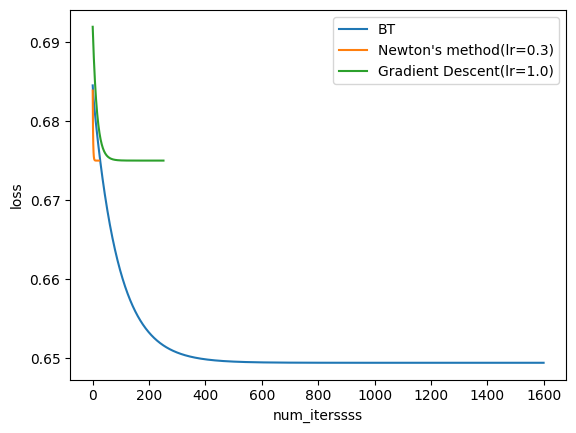

In [35]:
plt.plot(losses_epoch, label="BT")
plt.plot(torch.as_tensor(newton_losses), label="Newton's method(lr=0.3)")
plt.plot(torch.as_tensor(losses), label="Gradient Descent(lr=1.0)")
plt.xlabel("num_iterssss")
plt.ylabel("loss")
plt.legend()

In [36]:
with torch.no_grad():
    S = model.strength.weight.squeeze().numpy()
    S = S - S.mean()

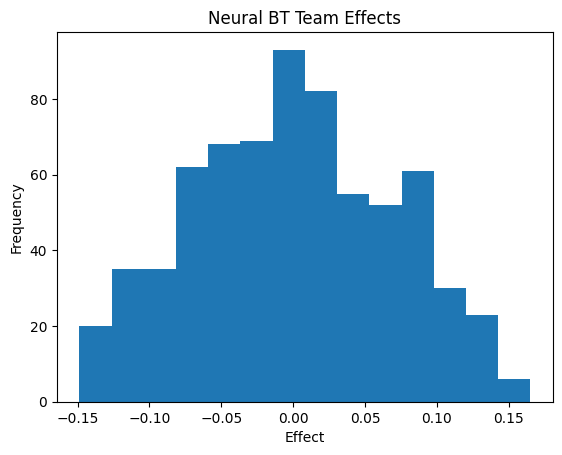

In [37]:
df_nbt_beta = pd.DataFrame({"Team": teams, "Effect": S})

plt.hist(df_nbt_beta["Effect"], bins='auto')
plt.title("Neural BT Team Effects")
plt.xlabel("Effect")
plt.ylabel("Frequency")
plt.show()

In [38]:
# top-10
teams_10_nbt = df_nbt_beta.sort_values(by="Effect", ascending=False).head(10)
teams_10_nbt

,Team,Effect
303,Liberty,0.165172
631,Washington,0.156707
347,Michigan,0.156175
558,Texas,0.146129
129,Colorado Mines,0.145859
196,Florida State,0.144211
214,Georgia,0.142652
271,Johns Hopkins,0.135894
549,Susquehanna,0.134814
436,Ohio State,0.134389


In [39]:
compare_ = pd.concat(
    [
      teams_10_gd.reset_index(drop=True),
      teams_10_n_gd.reset_index(drop=True),
      teams_10_nbt.reset_index(drop=True),
    ],
    axis=1,
    keys=["GD", "Newton", "SGD+Home Advantage"]
)
compare_.head(10)

GD                        Newton            \
                 Team    Effect                Team    Effect   
0             Liberty  0.169892             Liberty  0.169881   
1          Washington  0.160030          Washington  0.160027   
2            Michigan  0.159504            Michigan  0.159500   
3               Texas  0.147884               Texas  0.147884   
4             Georgia  0.147814             Georgia  0.147814   
5      Colorado Mines  0.147378      Colorado Mines  0.147376   
6       Florida State  0.145838       Florida State  0.145834   
7  South Dakota State  0.136141  South Dakota State  0.136144   
8       Johns Hopkins  0.135715       Johns Hopkins  0.135717   
9             Alabama  0.134950             Alabama  0.134951   

  SGD+Home Advantage            
                Team    Effect  
0            Liberty  0.165172  
1         Washington  0.156707  
2           Michigan  0.156175  
3              Texas  0.146129  
4     Colorado Mines  0.145859  
5      Florida State  0.144211  
6            Georgia  0.142652  
7      Johns Hopkins  0.135894  
8        Susquehanna  0.134814  
9         Ohio State  0.134389

### Problem 4.2: Evaluation
Assess whether or not your change was an improvement or not. Provide empirical evidence by evaluating performance on a held out test set and include at least one plot supporting your assessment.

Answer: We will use different splitting methods to split the training/test set (all other parameters are the same).

In [40]:
from sklearn.model_selection import train_test_split

################################################################################################################
idx = np.arange(len(home_idx))

train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

train_home = home_idx[train_idx]
train_away = away_idx[train_idx]
tarin_y = Y_N[train_idx]

test_home = home_idx[test_idx]
test_away = away_idx[test_idx]
test_y = Y_N[test_idx]
################################################################################################################

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [41]:
def evaluate_pytorch_model(model, home_idx, away_idx, target_y):
  model.eval()
  
  with torch.no_grad():
    
    logits = model(home_idx, away_idx)
    
    # If logits > 0, it means the model predicts the home team will win.
    preds = (logits >= 0).float()
    
    accuracy = (preds == target_y).float().mean()
    
    return accuracy.item()
  
def evaluate_origin_bradley_terry(X, Y, beta):
  with torch.no_grad():
    
    logits = X @ beta
    
    preds = (logits >= 0).float()
    
    accuracy = (preds == Y).float().mean()
    
    return accuracy.item()

In [42]:
train_bn_acc = evaluate_pytorch_model(model, train_home, train_away, tarin_y)
test_bn_acc = evaluate_pytorch_model(model, test_home, test_away, test_y)

train_acc = evaluate_origin_bradley_terry(x_train, y_train, beta)
test_acc = evaluate_origin_bradley_terry(x_test, y_test, beta)

print(f"Improved Model -> Train Acc: {train_bn_acc:.4f}, Test Acc: {test_bn_acc:.4f}")
print(f"Origin Model -> Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Improved Model -> Train Acc: 0.5647, Test Acc: 0.5836
Origin Model -> Train Acc: 0.8468, Test Acc: 0.8386


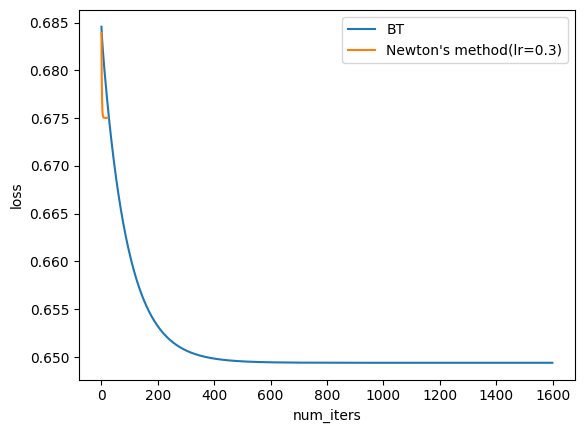

In [43]:
plt.plot(losses_epoch, label="BT")
plt.plot(torch.as_tensor(newton_losses), label="Newton's method(lr=0.3)")
plt.xlabel("num_iters")
plt.ylabel("loss")
plt.legend()

It turns out, by improving our model, we reduced our training loss (compared to the original model). However, a counterintuitive situation arose: <span style="color:green; font-weight:bold">the accuracy was far lower than that of our original model, and the improved version even achieved higher test accuracy than training accuracy.</span> This forced us to consider the reasons: was it due to ambiguity in the data or a problem with the model?

### Problem 4.3: Reflection
Reflecting on the analysis we've conducted in this assignemnt, which conference is best? Is there a significant difference? Please justify your answer.

Answer: We will 

In [44]:
df.head().T

,0,1,2,3,4
Id,401520145,401525450,401532392,401540628,401520147
Season,2023,2023,2023,2023,2023
Week,1,1,1,1,1
Season Type,regular,regular,regular,regular,regular
Start Date,2023-08-26T21:30:00.000Z,2023-08-26T23:00:00.000Z,2023-08-26T23:00:00.000Z,2023-08-26T23:00:00.000Z,2023-08-26T23:30:00.000Z
Start Time Tbd,False,False,False,False,False
Completed,True,True,True,True,True
Neutral Site,False,False,False,False,False
Conference Game,True,False,False,False,False
Attendance,17982.0,15356.0,23867.0,NaN,21407.0


In [45]:
home_con = df[["Home Team", "Home Conference"]].rename(columns={"Home Team":"Team", "Home Conference":"Conference"})
away_con = df[["Away Team", "Away Conference"]].rename(columns={"Away Team":"Team", "Away Conference":"Conference"})
team_to_con = pd.concat([home_con, away_con], ignore_index=True).drop_duplicates().set_index("Team")["Conference"].to_dict()

In [46]:
from itertools import islice

for i, (k, v) in enumerate(islice(team_to_con.items(), 5)):
    print(i, k, v)

0 Jacksonville State Conference USA
1 New Mexico State Conference USA
2 San Diego State Mountain West
3 Albany CAA
4 Vanderbilt SEC


In [47]:
# Bootstrap Sampling
df_newton_beta["Conference"] = df_newton_beta["Team"].map(team_to_con)
num_iters = 1000
bootstrap_data = []

# nlargest() -> Retrieves the top 12 most representative conferences
# value_counes() -> Counts the number of teams in each conference
# index -> Gets a list of these conference names
top_conferences = df_newton_beta["Conference"].value_counts().nlargest(10).index

In [48]:
for conf in top_conferences:
    conf_effects = df_newton_beta[df_newton_beta["Conference"] == conf]["Effect"].values
    
    if len(conf_effects) > 0:
        resampled_means = []
        
        for _ in range(num_iters):
            # Sampling with replacement from the current conference's effect values ​​generates a new sample of the same length
            sample = np.random.choice(conf_effects, size=len(conf_effects), replace=True)
            # Looping 1000 times => yields 1000 averages =>
            # approximating the sampling distribution of the average effect of this conference
            resampled_means.append(np.mean(sample))
        
        # Record the mean and 95% confidence interval
        # Low / High: 2.5% and 97.5% quantiles => 95% bootstrap confidence interval
        bootstrap_data.append({
            "Conference": conf,
            "Mean": np.mean(resampled_means),
            "Low": np.percentile(resampled_means, 2.5),
            "High": np.percentile(resampled_means, 97.5)
        })

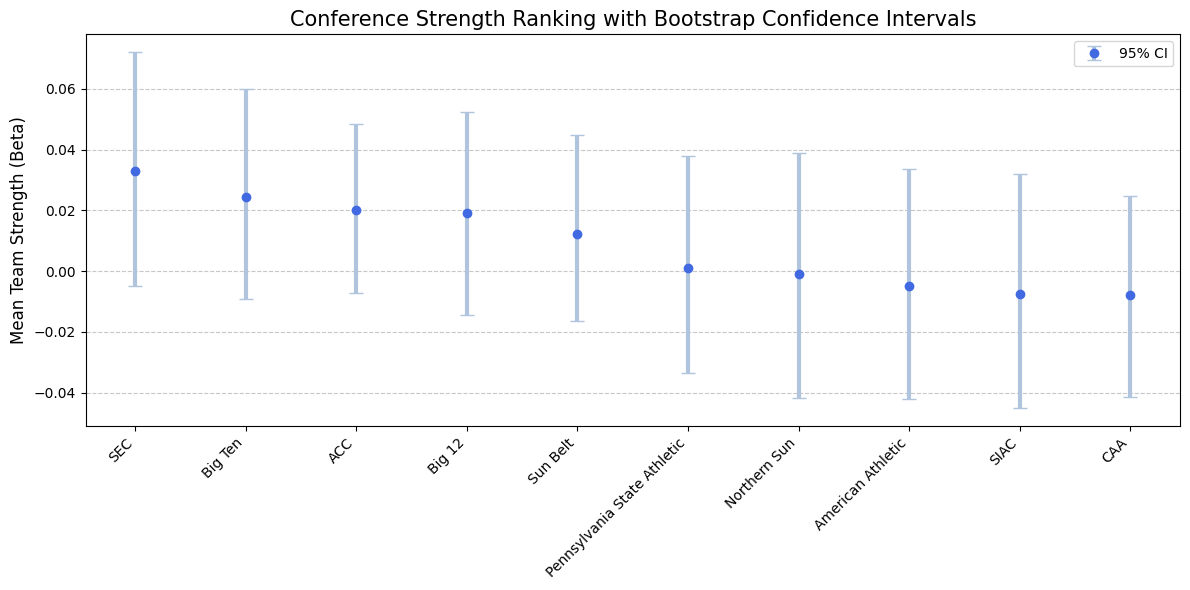

In [49]:
# Visualization: Draw an error bar chart with confidence intervals
df_boot = pd.DataFrame(bootstrap_data).sort_values(by='Mean', ascending=False)
plt.figure(figsize=(12, 6))
plt.errorbar(
    df_boot['Conference'], 
    df_boot['Mean'], 
    yerr=[df_boot['Mean'] - df_boot['Low'], df_boot['High'] - df_boot['Mean']], # Compute 95% confidence interval
    fmt='o', color='royalblue', ecolor='lightsteelblue', elinewidth=3, capsize=5, label='95% CI'
)

# Tilt the label at a 45-degree angle to avoid crowding, Right-aligned text on the horizontal axis
plt.xticks(rotation=45, ha='right')

plt.title("Conference Strength Ranking with Bootstrap Confidence Intervals", fontsize=15)
plt.ylabel("Mean Team Strength (Beta)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid
plt.legend()
plt.tight_layout() # Automatic layout adjustment
plt.show()

In [50]:
# Print the numerical results for Reflection to use
print("Bootstrap statistics (top 10):")
print(df_boot.head(10)[['Conference', 'Mean', 'Low', 'High']])

Bootstrap statistics (top 10):
                    Conference      Mean       Low      High
8                          SEC  0.032804 -0.004969  0.072054
6                      Big Ten  0.024548 -0.009026  0.059780
4                          ACC  0.020241 -0.007121  0.048391
2                       Big 12  0.019073 -0.014456  0.052340
5                     Sun Belt  0.012127 -0.016465  0.044824
0  Pennsylvania State Athletic  0.001176 -0.033369  0.037889
3                 Northern Sun -0.000934 -0.041574  0.038712
7            American Athletic -0.004774 -0.042059  0.033745
9                         SIAC -0.007587 -0.045146  0.031986
1                          CAA -0.007883 -0.041292  0.024712


By observing the 95% Confidence Intervals and Low values ​​in the above graph, we found that all Low values ​​are negative (<font color="red">the Low value of Top 1 crosses 0</font>) and the Confidence Intervals highly overlap (<font color="orange">meaning we cannot conclude that Top 1 is stronger than its competitors, nor can we confirm with 95% confidence that it is better than the entire league</font>). Although SEC ranks first, we found that this result is not statistically significant.

## Submission Instructions

**Formatting:** check that your code does not exceed 80 characters in line width. You can set _Tools &rarr; Settings &rarr; Editor &rarr; Vertical ruler column_ to 80 to see when you've exceeded the limit.

**Converting to PDF** The simplest way to convert to PDF is to use the "Print to PDF" option in your browser. Just make sure that your code and plots aren't cut off, as it may not wrap lines.

**Alternatively** You can download your notebook in .ipynb format and use the following commands to convert it to PDF.  Then run the following command to convert to a PDF:
```
jupyter nbconvert --to pdf <yourlastname>_hw<number>.ipynb
```
(Note that for the above code to work, you need to rename your file `<yourlastname>_hw<number>.ipynb`)

**Installing nbconvert:**

If you're using Anaconda for package management,
```
conda install -c anaconda nbconvert
```

**Upload** your .pdf file to Gradescope. Please tag your questions correctly! I.e., for each question, all of and only the relevant sections are tagged.

Please post on Ed or come to OH if there are any other problems submitting the HW.